# ON cell model comparisons

This notebook compares ON-cell model fits using LOO/ WAIC criteria.

In [1]:
import arviz as az
from rvm_analysis.plotting import plot_loo_comparison
from pathlib import Path

## Load the model traces

In [2]:
base_path: Path = Path("../Bayesian_trial_function_fits/models/on_models/")
models = {
    "Exp. \n + Exp.": "18_double_exponential_aggregated_counts",
    "Exp.": "19_single_exponential_aggregated_counts",
    # "Mean": "20_mean_func_aggregated_counts"
}

In [3]:
traces = {}
for name,path in models.items():
    full_path = base_path / path / "idata_with_log_liks.nc"
    print(full_path)
    traces[name] = az.from_netcdf(full_path)

..\Bayesian_trial_function_fits\models\on_models\18_double_exponential_aggregated_counts\idata_with_log_liks.nc
..\Bayesian_trial_function_fits\models\on_models\19_single_exponential_aggregated_counts\idata_with_log_liks.nc


In [4]:
df_comp_waic = az.compare(traces,ic='waic') # Alternatively use "loo"

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_waic (log)', ylabel='ranked models'>

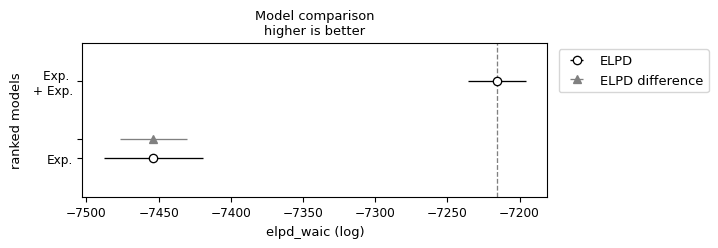

In [5]:
az.plot_compare(df_comp_waic, insample_dev=False)

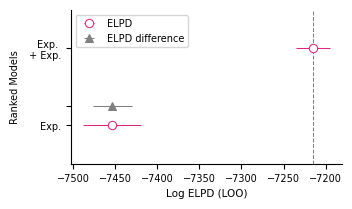

In [6]:
plot_loo_comparison(traces,cell_name="ON",figsize=(3.5,2),
                    filename="ON_cell_comparison_LOO",basePath="./models/on_models",svg=True,dpi=300,save=True)

In [7]:
df_comp_waic

,rank,elpd_waic,p_waic,elpd_diff,weight,se,dse,warning,scale
Exp. \n + Exp.,0,-7215.476804,4.425041,0.000000,1.000000e+00,20.128411,0.000000,False,log
Exp.,1,-7453.628151,6.264841,238.151347,3.256275e-09,34.550589,23.213481,False,log
